-------------------------------
#                                         Credit Card Fraud Detection
-------------------------------

In [36]:
# 1️⃣ IMPORT 
# =====================================
# Credit Card Fraud Detection
# =====================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, MinMaxScaler, StandardScaler
from sklearn.compose import ColumnTransformer


from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    auc, roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
import xgboost as xgb


import warnings
warnings.filterwarnings("ignore")


In [2]:
df = pd.read_csv("credit_card_fraud_dataset.csv")
df.head()


,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   TransactionID    100000 non-null  int64  
 1   TransactionDate  100000 non-null  object 
 2   Amount           100000 non-null  float64
 3   MerchantID       100000 non-null  int64  
 4   TransactionType  100000 non-null  object 
 5   Location         100000 non-null  object 
 6   IsFraud          100000 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 5.3+ MB


In [4]:
df.describe()

,TransactionID,Amount,MerchantID,IsFraud
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,2497.092666,501.676070,0.010000
std,28867.657797,1442.415999,288.715868,0.099499
min,1.000000,1.050000,1.000000,0.000000
25%,25000.750000,1247.955000,252.000000,0.000000
50%,50000.500000,2496.500000,503.000000,0.000000
75%,75000.250000,3743.592500,753.000000,0.000000
max,100000.000000,4999.770000,1000.000000,1.000000


In [5]:
print("Dataset shape:", df.shape)

print("\nFraud distribution:")
print(df['IsFraud'].value_counts())
print("\nFraud percentage:")
print(df['IsFraud'].value_counts(normalize=True) * 100)


Dataset shape: (100000, 7)

Fraud distribution:
IsFraud
0    99000
1     1000
Name: count, dtype: int64

Fraud percentage:
IsFraud
0    99.0
1     1.0
Name: proportion, dtype: float64


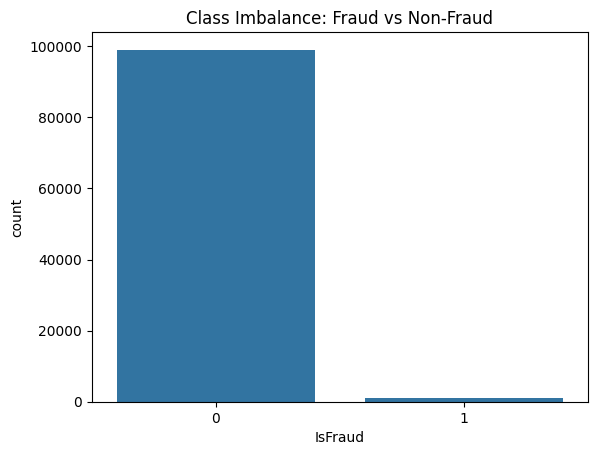

In [ ]:
sns.countplot(x="IsFraud", data=df)
plt.title("Class Imbalance: Fraud vs Non-Fraud")
plt.show()


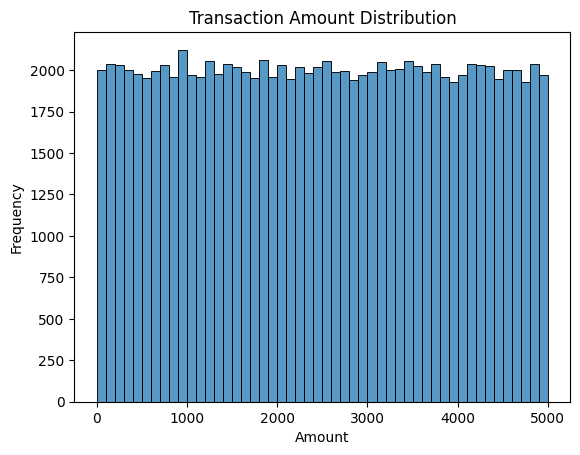

In [7]:
sns.histplot(df["Amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

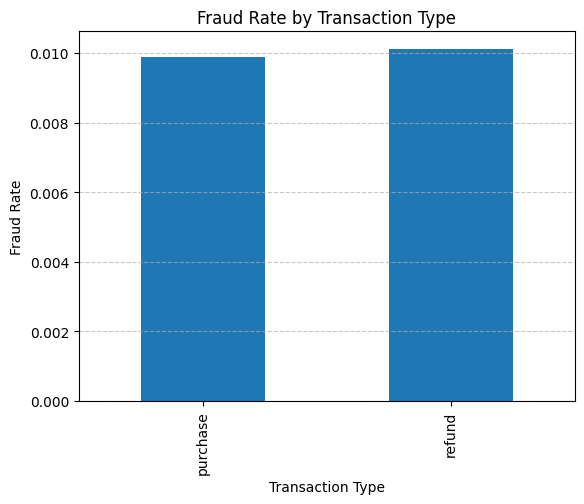

In [8]:
df.groupby("TransactionType")["IsFraud"].mean().plot(kind="bar")
plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate")
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

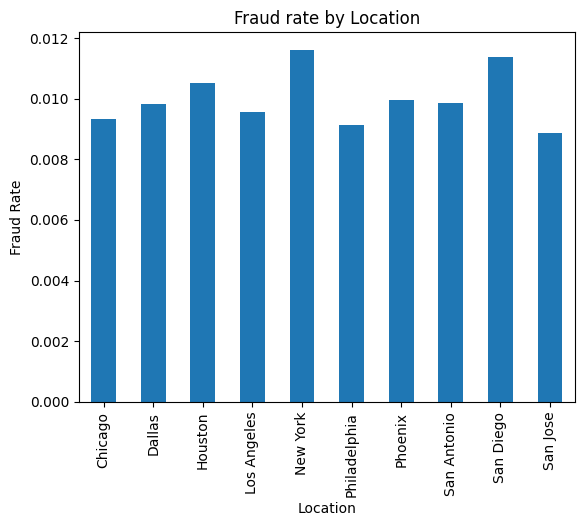

In [9]:
df.groupby("Location")["IsFraud"].mean().plot(kind="bar")
plt.title("Fraud rate by Location")
plt.xlabel("Location")
plt.ylabel("Fraud Rate")
plt.show()

In [10]:
# DROP ID 
df = df.drop(columns=["TransactionID","MerchantID"]) 


In [11]:
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])

df["hour"] = df["TransactionDate"].dt.hour
df["day"] = df["TransactionDate"].dt.day
df["weekday"] = df["TransactionDate"].dt.weekday
df["is_weekend"] = df["weekday"].isin([5,6]).astype(int)

df["is_night"] = ((df["hour"] >= 0) & (df["hour"] <= 5)).astype(int)

df["high_amount"] = (
    df["Amount"] > df["Amount"].quantile(0.95)
).astype(int)

df = df.drop(columns=["TransactionDate"])


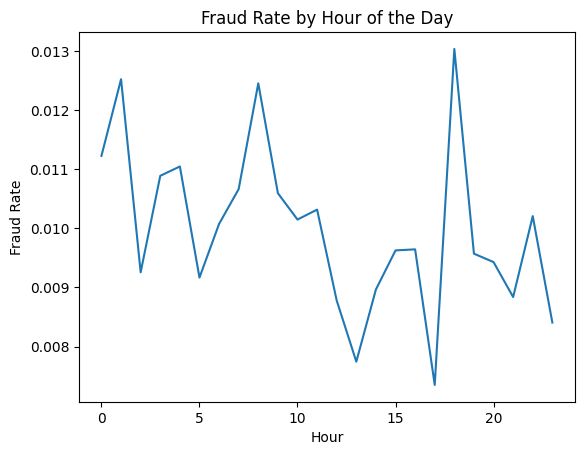

In [12]:
hourly_fraud = df.groupby("hour")["IsFraud"].mean()
hourly_fraud.plot()
plt.title("Fraud Rate by Hour of the Day")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate")
plt.show()

In [13]:
# One-hot encoding
df = pd.get_dummies(
    df,
    columns=["TransactionType", "Location"],
    drop_first=False
)
df

,Amount,IsFraud,hour,day,weekday,is_weekend,is_night,high_amount,TransactionType_purchase,TransactionType_refund,Location_Chicago,Location_Dallas,Location_Houston,Location_Los Angeles,Location_New York,Location_Philadelphia,Location_Phoenix,Location_San Antonio,Location_San Diego,Location_San Jose
0,4189.27,0,14,3,2,0,0,0,False,True,False,False,False,False,False,False,False,True,False,False
1,2659.71,0,13,19,1,0,0,0,False,True,False,True,False,False,False,False,False,False,False,False
2,784.00,0,10,8,0,0,0,0,True,False,False,False,False,False,True,False,False,False,False,False
3,3514.40,0,23,13,5,1,0,0,True,False,False,False,False,False,False,True,False,False,False,False
4,369.07,0,18,12,4,0,0,0,True,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1057.29,0,0,7,4,0,1,0,False,True,False,False,False,False,False,False,False,True,False,False
99996,297.25,0,23,22,6,1,0,0,False,True,False,False,False,False,False,False,False,True,False,False
99997,3448.56,0,19,31,4,0,0,0,True,False,False,False,False,False,False,False,False,True,False,False
99998,3750.79,0,9,18,4,0,0,0,True,False,False,False,False,False,False,True,False,False,False,False


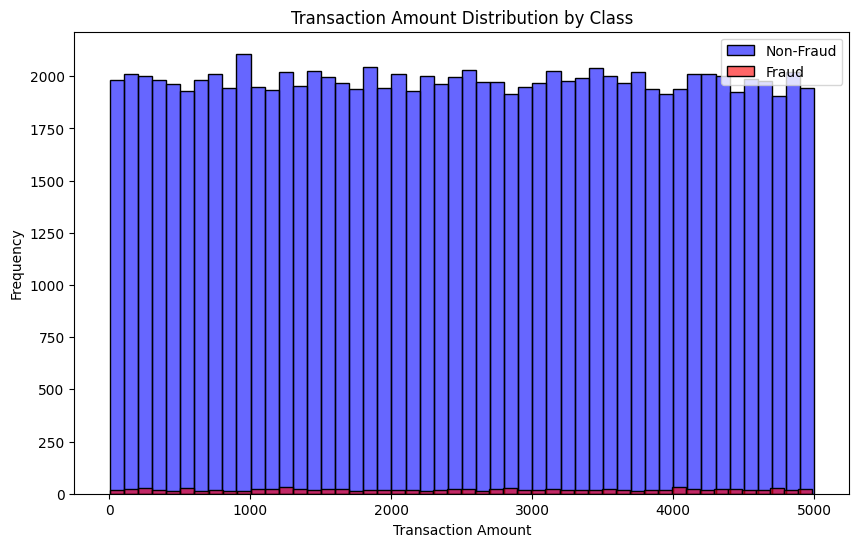

In [14]:
# lets to some visualization to understand the data better.
plt.figure(figsize=(10, 6))
sns.histplot(df[df['IsFraud'] == 0]['Amount'], bins=50  , color='blue', label='Non-Fraud', alpha=0.6)
sns.histplot(df[df['IsFraud'] == 1]['Amount'], bins=50, color='red', label='Fraud', alpha=0.6)
plt.title('Transaction Amount Distribution by Class')   
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.legend()
plt.show() 

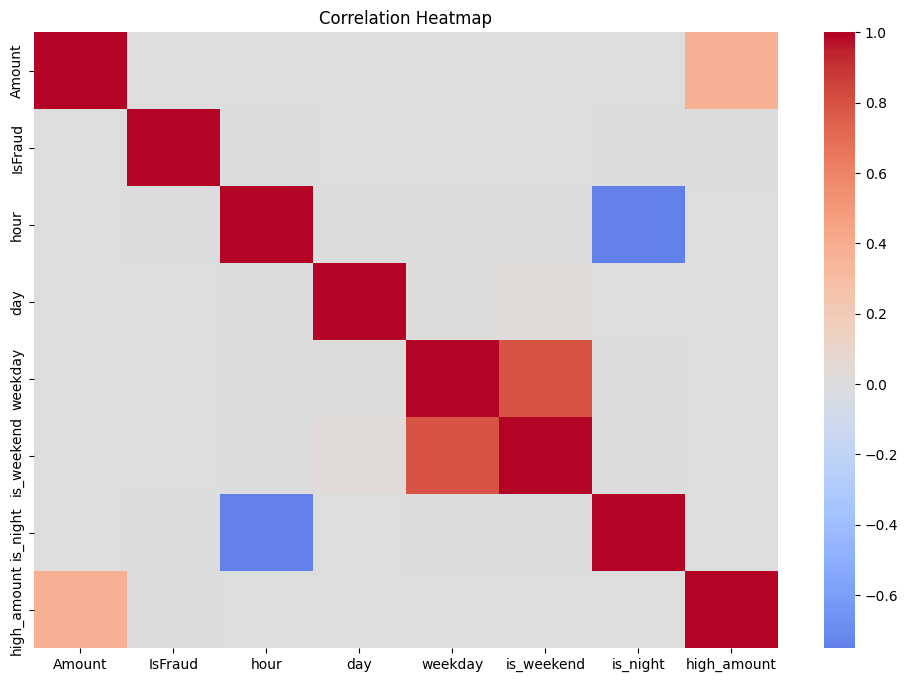

In [15]:
# next visualization is to see the correlation between features and the target variable.
plt.figure(figsize=(12,8))

# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.show()


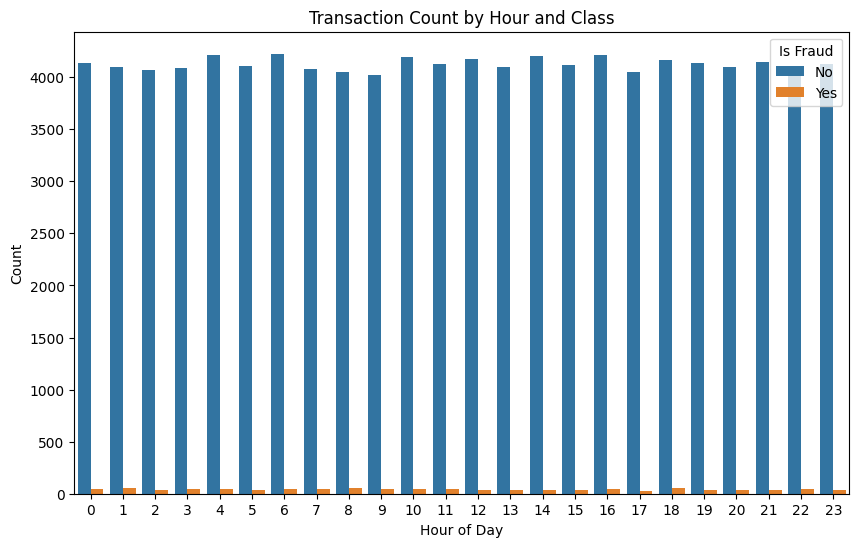

In [17]:
# next visualization on the distribution of transactions by hour of the day.
plt.figure(figsize=(10, 6))
sns.countplot(x="hour", hue="IsFraud", data=df)
plt.title("Transaction Count by Hour and Class")
plt.xlabel("Hour of Day")
plt.ylabel("Count")
plt.legend(title="Is Fraud", labels=["No", "Yes"])
plt.show()

In [18]:
# TRAIN and TEST SPLIT

X = df.drop("IsFraud", axis=1)
y = df["IsFraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [ ]:
# SCALING 

# Preprocessor definition
preprocessor = ColumnTransformer(
    transformers=[
        ("robust", RobustScaler(), ["Amount"]),       # skewed continuous
        ("minmax", MinMaxScaler(), ["hour", "day","weekday"]), # ordinal/time
    ],
    remainder="passthrough"  # keep binary flags like is_weekend untouched
)


# Fit on training, transform both sets
X_train_p = preprocessor.fit_transform(X_train)
X_test_p = preprocessor.transform(X_test)

# TRAIN ISOLATION FOREST

In [20]:
X_train_normal = X_train_p[y_train == 0]

iso = IsolationForest(
    n_estimators=200,
    contamination=0.01,
    random_state=42
)

iso.fit(X_train_normal)

iso_pred = iso.predict(X_test_p)
iso_pred = (iso_pred == -1).astype(int)

print("Isolation Forest Report")
print(classification_report(y_test, iso_pred))
print(confusion_matrix(y_test, iso_pred))
print("ROC-AUC:", roc_auc_score(y_test, iso_pred))


Isolation Forest Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     19800
           1       0.01      0.01      0.01       200

    accuracy                           0.98     20000
   macro avg       0.50      0.50      0.50     20000
weighted avg       0.98      0.98      0.98     20000

[[19594   206]
 [  198     2]]
ROC-AUC: 0.4997979797979798


# TRAIN A BASELINE (Logistic Regression)

In [21]:
log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42,C=0.1, solver='saga',penalty='l2'
)

log_model.fit(X_train_p, y_train)

log_prob = log_model.predict_proba(X_test_p)[:, 1]
log_pred = log_model.predict(X_test_p)

print("Logistic ROC-AUC:", roc_auc_score(y_test, log_prob))
print(classification_report(y_test, log_pred))
print(confusion_matrix(y_test, log_pred))


Logistic ROC-AUC: 0.535334595959596
              precision    recall  f1-score   support

           0       0.99      0.66      0.79     19800
           1       0.01      0.40      0.02       200

    accuracy                           0.66     20000
   macro avg       0.50      0.53      0.41     20000
weighted avg       0.98      0.66      0.78     20000

[[13079  6721]
 [  120    80]]


# RANDOM FOREST

In [22]:
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    min_samples_split=9,
    min_samples_leaf=9,
    max_depth=None,
    criterion='gini',
    oob_score=True,
    max_features=0.5
)

rf.fit(X_train_p, y_train)

rf_prob = rf.predict_proba(X_test_p)[:, 1]
rf_pred = rf.predict(X_test_p)


# Lower threshold to improve recall
rf_pred_adj = (rf_prob > 0.1).astype(int)
print("Random Forest ROC-AUC:", roc_auc_score(y_test, rf_prob))
print(classification_report(y_test, rf_pred_adj))
print(confusion_matrix(y_test, rf_pred_adj))


Random Forest ROC-AUC: 0.5245691919191919
              precision    recall  f1-score   support

           0       0.99      0.77      0.86     19800
           1       0.01      0.28      0.02       200

    accuracy                           0.76     20000
   macro avg       0.50      0.53      0.44     20000
weighted avg       0.98      0.76      0.86     20000

[[15152  4648]
 [  143    57]]


In [ ]:
print("OOB Score:", rf.oob_score_) 
# OOB score means the model's performance on unseen data during training, providing an unbiased estimate of its generalization ability.

OOB Score: 0.9896875


# XgBoost

In [ ]:
ratio = (y_train == 0).sum() / (y_train == 1).sum() # ratio for scale_pos_weight

Xgb = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.7,
    min_child_weight=3,
    early_stopping_rounds=50,
    scale_pos_weight=ratio,
    eval_metric="aucpr",   
    random_state=42,
    tree_method= "hist",
    n_jobs=-1
)

# Fit with early stopping
Xgb.fit(
    X_train_p, y_train,
    eval_set=[(X_test_p, y_test)],   
    verbose=50
)
xgb_prob = Xgb.predict_proba(X_test_p)[:,1]
xgb_pred = Xgb.predict(X_test_p)
print("XGBOOST ROC_AUC:", roc_auc_score(y_test, xgb_prob))

print(classification_report(y_test, xgb_pred))
print(confusion_matrix(y_test, xgb_pred))


[0]	validation_0-aucpr:0.01054
[50]	validation_0-aucpr:0.00959
[51]	validation_0-aucpr:0.00955
XGBOOST ROC_AUC: 0.5303546717171718
              precision    recall  f1-score   support

           0       0.99      0.64      0.78     19800
           1       0.01      0.42      0.02       200

    accuracy                           0.64     20000
   macro avg       0.50      0.53      0.40     20000
weighted avg       0.98      0.64      0.77     20000

[[12672  7128]
 [  115    85]]


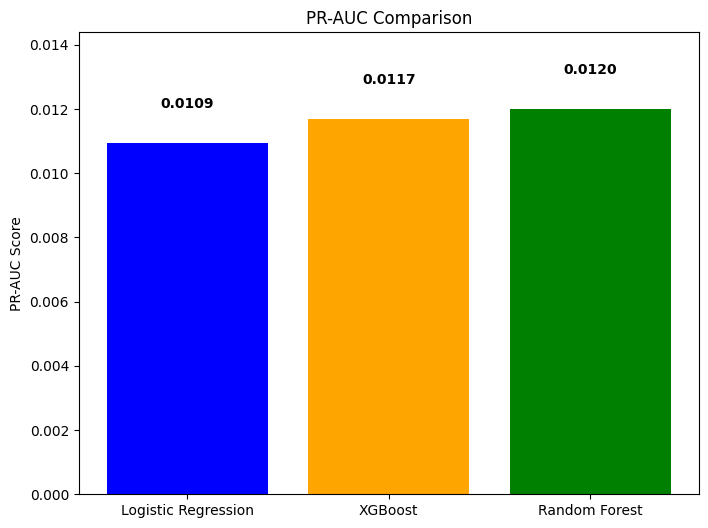

Logistic Regression PR-AUC: 0.010939744405457799
XGBoost PR-AUC: 0.011684661508358214
Random Forest PR-AUC: 0.011990237892477749


In [28]:
# --- Compute PR-AUC for all models ---
log_precision, log_recall, _ = precision_recall_curve(y_test, log_prob)
xgb_precision, xgb_recall, _ = precision_recall_curve(y_test, xgb_prob)
rf_precision, rf_recall, _   = precision_recall_curve(y_test, rf_prob)

log_pr_auc = auc(log_recall, log_precision)
xgb_pr_auc = auc(xgb_recall, xgb_precision)
rf_pr_auc  = auc(rf_recall, rf_precision)

# --- Plot PR-AUC bar chart with values ---
plt.figure(figsize=(8,6))
models = ["Logistic Regression", "XGBoost", "Random Forest"]
pr_aucs = [log_pr_auc, xgb_pr_auc, rf_pr_auc]
bars = plt.bar(models, pr_aucs, color=["blue","orange","green"])

plt.title("PR-AUC Comparison")
plt.ylabel("PR-AUC Score")
plt.ylim(0, max(pr_aucs)*1.2)

# Annotate each bar with its value
for bar, value in zip(bars, pr_aucs):
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        bar.get_height() + 0.001, 
        f"{value:.4f}", 
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.show()

# Print values for clarity
print("Logistic Regression PR-AUC:", log_pr_auc)
print("XGBoost PR-AUC:", xgb_pr_auc)
print("Random Forest PR-AUC:", rf_pr_auc)


In [29]:
# Random Forest feature importance

importances = rf.feature_importances_
feat_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print("RANDOM FOREST")
print(feat_imp.head(15))

RANDOM FOREST
                     Feature  Importance
0                     Amount    0.333782
2                        day    0.196269
1                       hour    0.172342
3                    weekday    0.088338
16      Location_San Antonio    0.017380
15          Location_Phoenix    0.016000
11          Location_Houston    0.015582
14     Location_Philadelphia    0.015398
9           Location_Chicago    0.015310
12      Location_Los Angeles    0.015221
10           Location_Dallas    0.014975
18         Location_San Jose    0.014936
17        Location_San Diego    0.014923
13         Location_New York    0.014902
7   TransactionType_purchase    0.014616


In [30]:
# Random Forest feature importance

importances = Xgb.feature_importances_
feat_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print("XGBOOST")
print(feat_imp.head(15))


XGBOOST
                   Feature  Importance
0                   Amount    0.068953
9         Location_Chicago    0.063196
12    Location_Los Angeles    0.058583
14   Location_Philadelphia    0.058561
16    Location_San Antonio    0.057482
2                      day    0.056136
1                     hour    0.056126
3                  weekday    0.055747
11        Location_Houston    0.054628
17      Location_San Diego    0.052314
13       Location_New York    0.051209
8   TransactionType_refund    0.051062
18       Location_San Jose    0.050646
10         Location_Dallas    0.048631
6              high_amount    0.045998


In [31]:
coef = log_model.coef_[0]

feat_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": coef,
    "AbsValue": np.abs(coef)
}).sort_values("AbsValue", ascending=False)

print("LogisticRegression")
print(feat_imp.head(15))

LogisticRegression
                     Feature  Coefficient  AbsValue
4                 is_weekend     8.618671  8.618671
3                    weekday     7.275526  7.275526
14     Location_Philadelphia     6.516759  6.516759
2                        day    -5.694557  5.694557
15          Location_Phoenix    -5.454938  5.454938
5                   is_night     5.392423  5.392423
7   TransactionType_purchase    -5.266759  5.266759
9           Location_Chicago     3.850556  3.850556
1                       hour    -3.338697  3.338697
17        Location_San Diego    -3.093731  3.093731
12      Location_Los Angeles    -1.889621  1.889621
13         Location_New York    -1.574220  1.574220
18         Location_San Jose    -1.403581  1.403581
16      Location_San Antonio    -1.364193  1.364193
8     TransactionType_refund     1.082312  1.082312


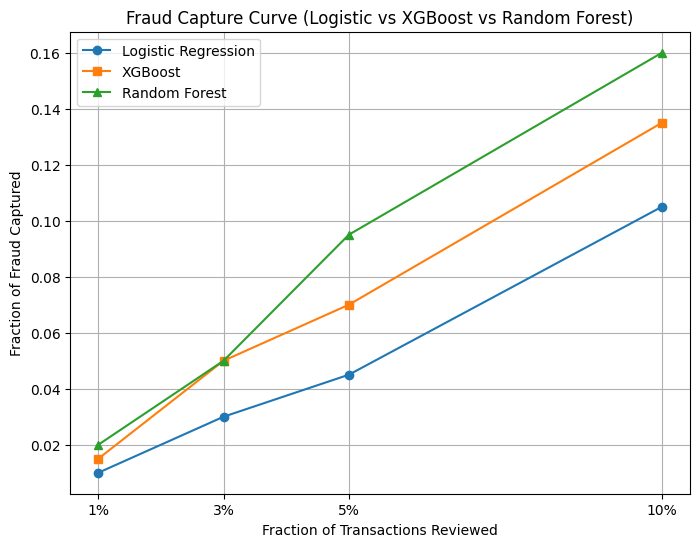


Fraud Capture Comparison Table:
     Logistic Regression  XGBoost  Random Forest
1%                 0.010    0.015          0.020
3%                 0.030    0.050          0.050
5%                 0.045    0.070          0.095
10%                0.105    0.135          0.160


In [32]:
# --- Function to compute fraud capture at K ---
def fraud_capture_curve(y_true, y_prob, ks=[0.01, 0.03, 0.05, 0.10]):
    results = {}
    df_eval = pd.DataFrame({"y": y_true, "prob": y_prob}).sort_values("prob", ascending=False)
    total_fraud = y_true.sum()
    for k in ks:
        cutoff = int(len(df_eval) * k)
        captured = df_eval.head(cutoff)["y"].sum() / total_fraud
        results[k] = captured
    return results

# --- Compute curves for all models ---
log_results = fraud_capture_curve(y_test, log_prob)
xgb_results = fraud_capture_curve(y_test, xgb_prob)
rf_results  = fraud_capture_curve(y_test, rf_prob)

# --- Plot side-by-side curves ---
plt.figure(figsize=(8,6))
plt.plot(list(log_results.keys()), list(log_results.values()), marker='o', label="Logistic Regression")
plt.plot(list(xgb_results.keys()), list(xgb_results.values()), marker='s', label="XGBoost")
plt.plot(list(rf_results.keys()), list(rf_results.values()), marker='^', label="Random Forest")

plt.title("Fraud Capture Curve (Logistic vs XGBoost vs Random Forest)")
plt.xlabel("Fraction of Transactions Reviewed")
plt.ylabel("Fraction of Fraud Captured")
plt.xticks([0.01, 0.03, 0.05, 0.10], ["1%", "3%", "5%", "10%"])
plt.legend()
plt.grid(True)
plt.show()

results_df = pd.DataFrame({
    "Logistic Regression": log_results,
    "XGBoost": xgb_results,
    "Random Forest": rf_results
})
results_df.index = [f"{int(k*100)}%" for k in results_df.index]
print("\nFraud Capture Comparison Table:")
print(results_df)

# Threshold Optimization

In [33]:
import pandas as pd
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix

def optimize_threshold(y_true, y_prob, beta=2):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    fbeta_scores = (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall + 1e-9)
    best_idx = np.argmax(fbeta_scores)
    best_threshold = thresholds[best_idx]
    return best_threshold

def evaluate_model(name, y_true, y_prob, beta=2):
    threshold = optimize_threshold(y_true, y_prob, beta)
    preds = (y_prob >= threshold).astype(int)
    report = classification_report(y_true, preds, output_dict=True)
    cm = confusion_matrix(y_true, preds)
    return {
        "Model": name,
        "Threshold": round(threshold, 4),
        "Precision (Fraud)": round(report["1"]["precision"], 4),
        "Recall (Fraud)": round(report["1"]["recall"], 4),
        "F2-Score": round((5 * report["1"]["precision"] * report["1"]["recall"]) /
                            (4 * report["1"]["precision"] + report["1"]["recall"] + 1e-9), 4),
        "Confusion Matrix": cm.tolist()
    }

# --- Evaluate all models ---
results = []
results.append(evaluate_model("Logistic Regression", y_test, log_prob))
results.append(evaluate_model("XGBoost", y_test, xgb_prob))
results.append(evaluate_model("Random Forest", y_test, rf_prob))

# --- Create comparison table ---
results_df = pd.DataFrame(results)
print("\nOptimized Threshold Comparison Table:")
print(results_df)



Optimized Threshold Comparison Table:
                 Model  Threshold  Precision (Fraud)  Recall (Fraud)  \
0  Logistic Regression     0.6288             0.0122            0.39   
1              XGBoost     0.5017             0.0127            0.32   
2        Random Forest     0.1464             0.0164            0.16   

   F2-Score            Confusion Matrix  
0    0.0541  [[13468, 6332], [122, 78]]  
1    0.0546  [[14805, 4995], [136, 64]]  
2    0.0581  [[17880, 1920], [168, 32]]  


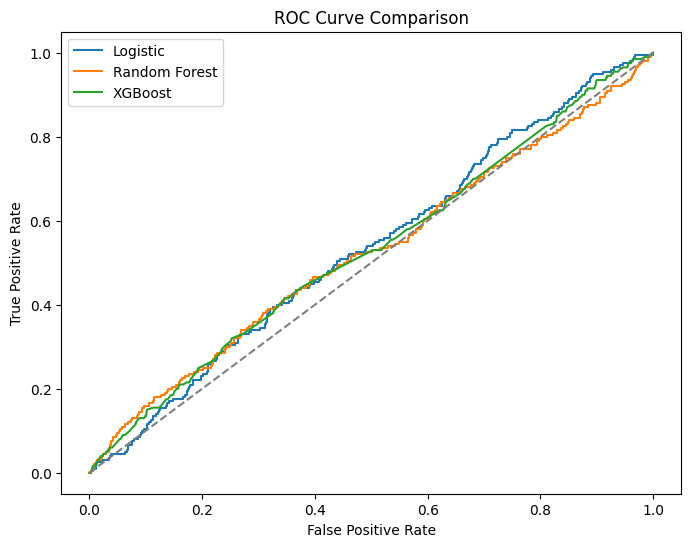

In [ ]:
# ROC CURVE COMPARISON

plt.figure(figsize=(8,6))

for name, probs in [
    ("Logistic", log_prob),
    ("Random Forest", rf_prob),
    ("XGBoost", xgb_prob)
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

-------------------------------------
# SAVE TRAINED MODEL & PREPROCESSOR
-------------------------------------


In [35]:
# =====================================
# SAVE TRAINED ARTIFACTS
# =====================================

import os
import joblib
import numpy as np
import pandas as pd

# Create artifacts directory
ARTIFACTS_DIR = "artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# -------------------------------------
# Save Final Random Forest Model
# -------------------------------------
model_path = os.path.join(
    ARTIFACTS_DIR,
    "fraud_rf_model.pkl"
)

joblib.dump(rf, model_path)

# -------------------------------------
# Save Preprocessor
# -------------------------------------
preprocessor_path = os.path.join(
    ARTIFACTS_DIR,
    "preprocessor.pkl"
)

joblib.dump(preprocessor, preprocessor_path)

# -------------------------------------
# Save Optimized Threshold
# -------------------------------------
best_rf_threshold = optimize_threshold(
    y_test,
    rf_prob
)

threshold_path = os.path.join(
    ARTIFACTS_DIR,
    "rf_threshold.pkl"
)

joblib.dump(best_rf_threshold, threshold_path)

# -------------------------------------
# Save Reference Risk Scores
# -------------------------------------
train_risk_scores = rf.predict_proba(
    X_train_p
)[:, 1]

reference_scores_path = os.path.join(
    ARTIFACTS_DIR,
    "reference_scores.npy"
)

np.save(
    reference_scores_path,
    train_risk_scores
)

# -------------------------------------
# Save Feature Column Order
# -------------------------------------
feature_columns = X.columns.tolist()

feature_columns_path = os.path.join(
    ARTIFACTS_DIR,
    "feature_columns.pkl"
)

joblib.dump(
    feature_columns,
    feature_columns_path
)

# -------------------------------------
# Save Feature Importance Table
# -------------------------------------
rf_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance_path = os.path.join(
    ARTIFACTS_DIR,
    "rf_feature_importance.csv"
)

rf_feature_importance.to_csv(
    feature_importance_path,
    index=False
)

# -------------------------------------
# Success Message
# -------------------------------------
print("✅ All artifacts saved successfully!")

print("\nSaved Files:")
print("Model:", model_path)
print("Preprocessor:", preprocessor_path)
print("Threshold:", threshold_path)
print("Reference Scores:", reference_scores_path)
print("Feature Columns:", feature_columns_path)
print("Feature Importance:", feature_importance_path)

✅ All artifacts saved successfully!

Saved Files:
Model: artifacts\fraud_rf_model.pkl
Preprocessor: artifacts\preprocessor.pkl
Threshold: artifacts\rf_threshold.pkl
Reference Scores: artifacts\reference_scores.npy
Feature Columns: artifacts\feature_columns.pkl
Feature Importance: artifacts\rf_feature_importance.csv
